# 12 · Random Forest + Kriging

Template para `RegressionKrigingModel`, separando claramente la parte no lineal del bosque y el ajuste espacial sobre residuos.

## Hipótesis del modelo

- El Random Forest captura relaciones no lineales y umbrales.
- El kriging sobre residuos agrega estructura espacial que el bosque no explica por sí solo.
- La interpretación puede combinar importancia global de features con mapas de residuo antes y después del kriging.

In [ ]:
from pathlib import Path
import sys
import pandas as pd
import geopandas as gpd
import seaborn as sns


PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from ml_core.models.rfrkModel import RegressionKrigingModel
from ml_core.evaluation.modelEvaluator import regression_metrics
from ml_core.visualization.mapper import ZTestMapVisualizer

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "12_rf_kriging"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

## Datos y configuración

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "splits"

train_raw = pd.read_csv(DATA_PATH / "arg_venta_data_train.csv")
gdf_train = gpd.GeoDataFrame(
    train_raw,
    geometry=gpd.points_from_xy(
        train_raw["longitud"],
        train_raw["latitud"]
    ),
    crs="EPSG:4326"
)

test_raw = pd.read_csv(DATA_PATH / "arg_venta_data_test.csv")
gdf_test = gpd.GeoDataFrame(
    test_raw,
    geometry=gpd.points_from_xy(
        test_raw["longitud"],
        test_raw["latitud"]
    ),
    crs="EPSG:4326"
)

val_raw = pd.read_csv(DATA_PATH / "arg_venta_data_val.csv")
gdf_val = gpd.GeoDataFrame(
    val_raw,
    geometry=gpd.points_from_xy(
        val_raw["longitud"],
        val_raw["latitud"]
    ),
    crs="EPSG:4326"
)



target_col = "log_precio"   
coord_cols = ["longitud", "latitud"]
feature_cols = [
    'area_m2_total',
    'area_m2_descubierta',
    'ambientes',
    'antiguedad',
    'expensas',
    'banos',
    'cocheras',
    'estado_num',
    'disposicion_Frente',
    'disposicion_Contrafrente',
    'disposicion_Lateral',
    'dist_subte',
    'dist_universidad',
    'dist_hospital',
    'dist_est_educativo',
    'dist_espacio_verde',
    'dist_areas_programaticas',
    'dist_avenida_rivadavia',
    "n_robos_1000m",
    "n_universidades_1000m",
    "pozo",
    "velocidad_ventas_1000m_90d"
]



In [3]:
X_train = gdf_train[feature_cols]
y_train = gdf_train[target_col]
coords_train = gdf_train[coord_cols].to_numpy()

X_test = gdf_test[feature_cols]
y_test = gdf_test[target_col]
coords_test = gdf_test[coord_cols].to_numpy()

X_val = gdf_val[feature_cols]
y_val = gdf_val[target_col]
coords_val = gdf_val[coord_cols].to_numpy()

## Entrenamiento

In [4]:
rf_params = {
    "n_estimators": 500,
    "max_depth": None,
    "min_samples_leaf": 3,
    "max_features": "log2",
}

kriging_params = {
    "n_closest_points": 7,
    "variogram_model": "linear",
    "pseudo_inv": True,
    "pseudo_inv_type": "pinvh",
}

model = RegressionKrigingModel(rf_params=rf_params, kriging_params=kriging_params, use_kriging=False)
model.fit(X_train, y_train, coords_train)
model


In [5]:

model.tune_hyperparameters(X_test, y_test.values.ravel(), coords_test)
best_config = {"RegressionKriging_params": rf_params, "kriging_params": kriging_params, "selected_k": getattr(model, "kriging_params_", {}).get("n_closest_points", None)}
best_config


/home/saneliges/Escritorio/PredictorPrecioMetroCuadradoAlquileres/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/saneliges/Escritorio/PredictorPrecioMetroCuadradoAlquileres/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/saneliges/Escritorio/PredictorPrecioMetroCuadradoAlquileres/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn co

{'RegressionKriging_params': {'n_estimators': 500,
  'max_depth': 20,
  'min_samples_leaf': 1,
  'max_features': 0.5,
  'bootstrap': True,
  'min_samples_split': 2},
 'kriging_params': {'n_closest_points': 7,
  'variogram_model': 'linear',
  'pseudo_inv': True,
  'pseudo_inv_type': 'pinvh'},
 'selected_k': None}

## Tuning tentativo

Acá podés barrer hiperparámetros del bosque y del kriging, o hacer primero tuning del RF y después del componente espacial.

## Evaluación global

In [6]:
rf_params = best_config["RegressionKriging_params"]
kriging_params = best_config["kriging_params"]
model = RegressionKrigingModel(rf_params=rf_params, kriging_params=kriging_params, use_kriging=False)
model.fit(X_train, y_train, coords_train)
model

y_pred_log = model.predict(
    X_val,
    coords_val
)

# revertir log
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_val)

metrics = regression_metrics(
    y_true,
    y_pred
)

metrics

{'rmse': 38766.94460014966,
 'mae': 17011.58826760286,
 'r2': 0.9044686301737093,
 'bias': 4922.754803010998,
 'median_abs_error': 7326.753969940997,
 'mape': 10.292068690856757}

## Visualización


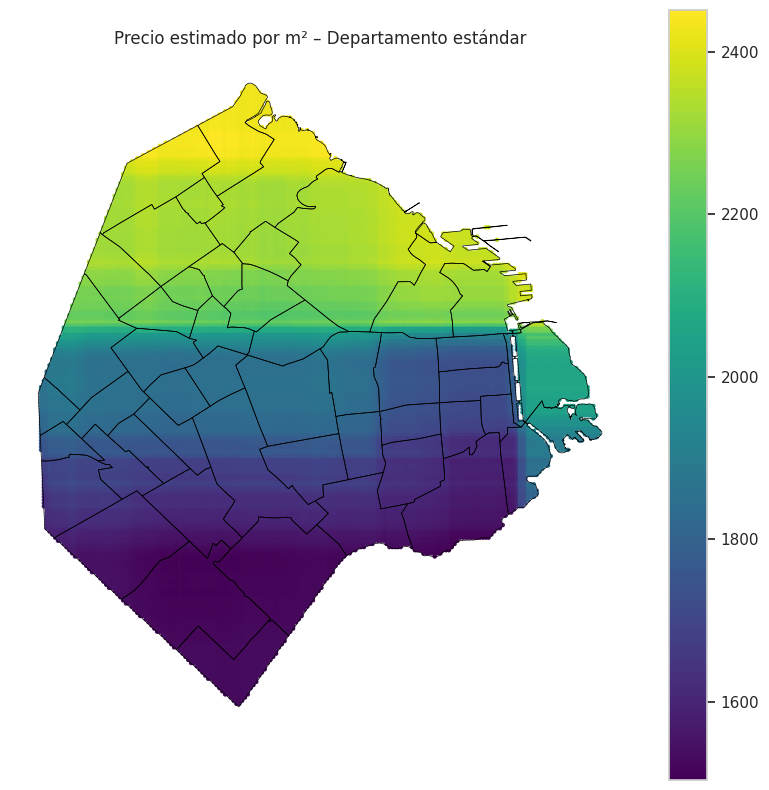

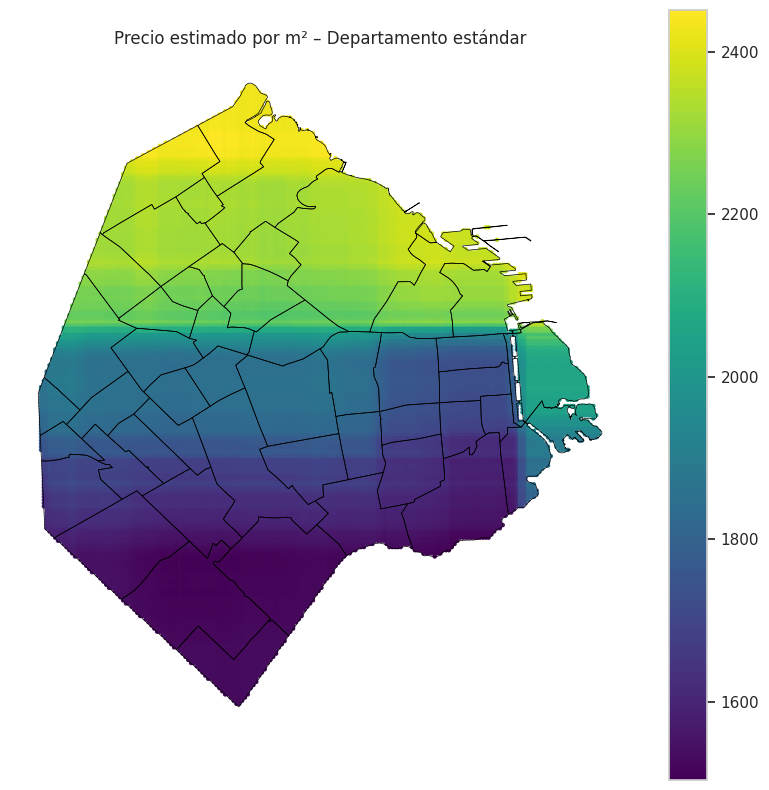

In [7]:
barrios_path = PROJECT_ROOT / 'GeoData' / 'barrios.geojson'

df_grid, barrios, std = generar_grid_predicciones(
    model,
    gdf_val,
    feature_cols
)

mapa = MapaPrecio(df_grid, barrios)

mapa.plot()

#mapa.save("mapa_modelo_lgwr.png")

#mapa.save("mapa_modelo_lgwr.pdf")



## Interpretación del Random Forest

In [8]:
# feature_importance = pd.DataFrame({
#     "feature": feature_cols,
#     "importance": model.feature_importances_(),
# }).sort_values("importance", ascending=False)
# feature_importance

## Residuo del bosque vs residuo final

Si querés entender el aporte del kriging, compará explícitamente el error del RF puro contra el error final del modelo combinado.

In [9]:
# model.feature_importances_(
#     X=X_test,
#     y=y_test,
#     coords=coords_test,
#     as_frame=True
# )


## Export

In [10]:
# test_export = test_df[[target_col] + coord_cols].copy()
# test_export = test_export.rename(columns={target_col: "y_true"})
# test_export["y_pred"] = np.asarray(y_pred).reshape(-1)
# test_export["residual"] = test_export["y_true"] - test_export["y_pred"]
# test_export["rf_only_pred"] = np.asarray(rf_only_pred).reshape(-1)
# test_export["split"] = "test"
# test_export.to_parquet(OUTPUT_DIR / "test_predictions.parquet", index=False)
# feature_importance.to_parquet(OUTPUT_DIR / "interpretability.parquet", index=False)
# run_config = {"rf_params": rf_params, "kriging_params": kriging_params}
# (OUTPUT_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2, ensure_ascii=False))
# (OUTPUT_DIR / "run_config.json").write_text(json.dumps(run_config, indent=2, ensure_ascii=False))

Oportunity detector?

In [ ]:
from ml_core.outlierAnalysis.oof import (
    detect_outliers_oof,
    load_active_processed_geodata,
)

rf_params = best_config["RegressionKriging_params"]
kriging_params = best_config["kriging_params"]


def build_rfrk_model():
    return RegressionKrigingModel(
        rf_params=rf_params,
        kriging_params=kriging_params,
        use_kriging=False,
    )


DATA_PATH = PROJECT_ROOT / "data" / "processed"

gdf_all = load_active_processed_geodata(
    data_path=DATA_PATH / "arg_venta_data_processed.csv",
    feature_cols=feature_cols,
    target_col=target_col,
    coord_cols=coord_cols,
    extra_cols=["idx", "url", "precio"],
)

X_all = gdf_all[feature_cols]
y_all = gdf_all[target_col]
coords_all = gdf_all[coord_cols].to_numpy()

results_by_method, residuals_oof = detect_outliers_oof(
    model_factory=build_rfrk_model,
    X=X_all,
    y=y_all,
    gdf=gdf_all,
    coords=coords_all,
    output_dir=OUTPUT_DIR / "outliers_oof",
    methods=["ztest","lisa"],
    params_for_methods={
        "ztest": {"alpha": 0.05}
                },
    k_neighbors=15,
    n_splits=5,
)

results_by_method["ztest"].head()




Fold 1/5


## Mapa interactivo de atipicidad (`ztest`)

Visualización de todos los avisos activos en CABA. Los avisos detectados como más atípicos según `ztest` aparecen con color más intenso; los no atípicos quedan en gris.


In [12]:
results.columns

Index(['idx', 'url', 'fold', 'method', 'precio', 'expensas',
       'area_m2_descubierta', 'area_m2_total', 'antiguedad', 'ambientes',
       'banos', 'latitud', 'longitud', 'valido_hasta', 'cocheras', 'pozo',
       'dist_subte', 'dist_universidad', 'dist_hospital', 'dist_est_educativo',
       'dist_espacio_verde', 'dist_areas_programaticas',
       'dist_avenida_rivadavia', 'n_universidades_1000m', 'n_robos_1000m',
       'velocidad_ventas_1000m_90d', 'estado_num', 'disposicion_Frente',
       'disposicion_Contrafrente', 'disposicion_Lateral', 'log_precio',
       'geometry', 'z_score', 'abs_z_score', 'tipo_valor_atipico'],
      dtype='str')

In [ ]:
from IPython.display import IFrame, display

ztest_visualizer = ZTestMapVisualizer(
    gdf_all=gdf_all,
    results_df=results_by_method["ztest"],
    barrios_path=PROJECT_ROOT / "GeoData" / "barrios.geojson"
)
ztest_map = ztest_visualizer.build_map()
ztest_map_path = OUTPUT_DIR / "outliers_oof" / "ztest_interactive_map.html"
ztest_visualizer.save_map(ztest_map_path)
display(IFrame(src=str(ztest_map_path.relative_to(PROJECT_ROOT)), width="100%", height=700))
